In [1]:
import cafe

# cafe.logger.setLevel("DEBUG")
logger = cafe.logger

INFO                                                                                                                                                                                                    
            _____     _ _ ______    _       ______            _                                                                                                                                         
           / ____|   | | |  ____|  | |     |  ____|          | |                                                                                                                                        
          | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __                                                                                                                     
          | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__|                                                                                                                

In [2]:
fadata = cafe.data.read_pancrease()
# fadata = fadata[:500]
fadata

AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'raw_index'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'id', 'cfe', 'filename'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'counts'
    obsp: 'distances', 'connectivities'

In [3]:
from cafe.method.function.cf_graph_mst import graph_mst

trajectory_dict = graph_mst(fadata)
trajectory_dict

{'wrapper_type': 'graph',
 'cell_graph':            from         to    length
 0      cell_000  cell_1099  9.136668
 1      cell_001  cell_1896  5.276772
 2      cell_001  cell_1132  5.995372
 3      cell_001  cell_3567  6.077523
 4      cell_001  cell_3372  6.082255
 ...         ...        ...       ...
 3688  cell_3544  cell_3671  4.948394
 3689  cell_3550  cell_3621  6.674201
 3690  cell_3550  cell_3644  6.690611
 3691  cell_3590  cell_3639  8.209218
 3692  cell_3630  cell_3656  6.034880
 
 [3693 rows x 3 columns],
 'to_keep': None}

WARNING  |- cell lost during trajectory graph construction: {'cell_1606', 'cell_2618'}                                                                                                                  
WARNING  |- The number of colors(2726) is greater than the number of colors in the 'Set3' palette(12), and the 'husl' palette selection is used.                                                        
INFO     |- prune_threshold: 0, milestone_network.shape: (2725, 4)                                                                                                                                      
WARNING  |- cell lost during trajectory graph construction: {'cell_1606', 'cell_2618'}                                                                                                                  
WARNING  |- dropping 479 cells because they map to milestones missing from the network.                                                                                                             

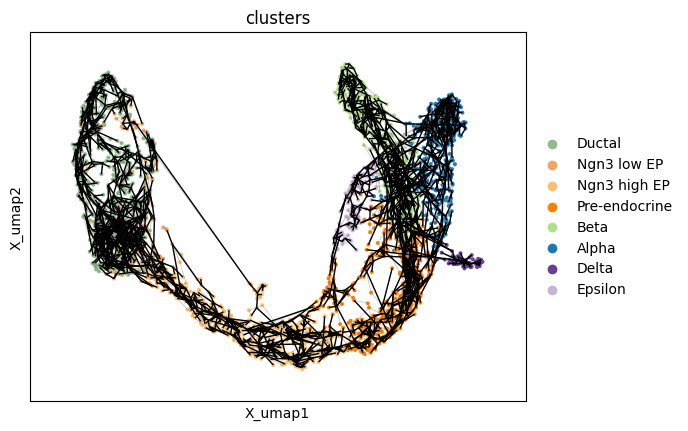

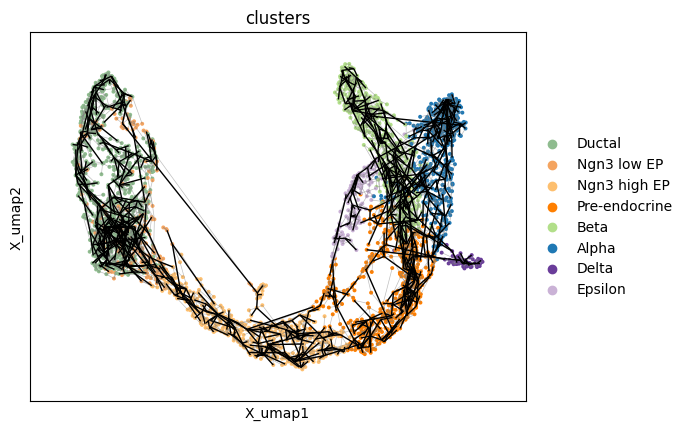

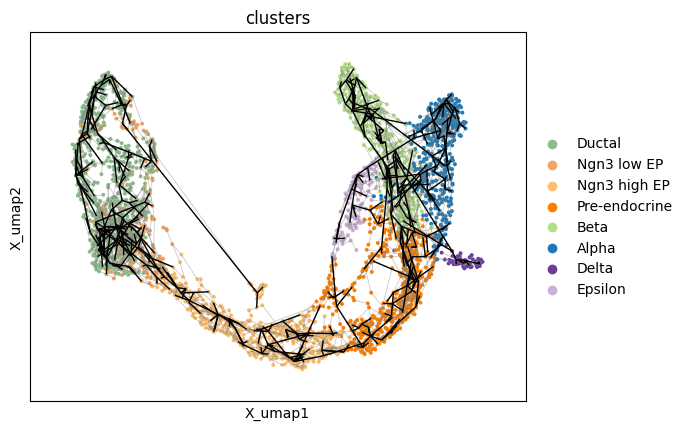

In [ ]:
prune_threshold_list = [0, 0.01, 0.1,]
# model_name_list = []

for prune_threshold in prune_threshold_list:
    id = f"prune_threshold_{prune_threshold}"
    # model_name_list.append(id)
    fadata.id = id

    wrapper_kargs = {"simplify_kwargs": {"prune_threshold": prune_threshold}}
    fadata.add_trajectory_by_type(trajectory_dict, **wrapper_kargs)

    mw = fadata.get_milestone_wrapper()
    logger.info(f"prune_threshold: {prune_threshold}, milestone_network.shape: {mw.milestone_network.shape}")
    cafe.plot.plot_wrapper(fadata, save=f"./img/25.11.26-multiscale_simplify/{id}.pdf")